# LSDL CUB, Homework 3. Constrastive Learning [10 pts]

This task is dedicated to contrastive self-supervised methods. We will focus on the SimCLR and BYOL algorithms that were discussed in class. We will conduct experiments on the [STL10](https://cs.stanford.edu/~acoates/stl10/) dataset, which is ideal for pretraining without labels, as it contains 100k unlabeled, 5k training labeled and 8k test labeled images.

To submit the task, you must conduct the experiments described in this notebook and write a report on them in PDF format. Along with the report, the code that allows you to run the experiments must be submitted. Before implementing anything, read all the experiment statements and think about how to better organize the code, do not forget to checkpoint the necessary trained models. We reserve the right to lower the grade for poorly structured code. Be sure to use the **training optimizations** from the [list](https://pytorch.org/tutorials/recipes/recipes/tuning_guide.html) in your pipelines, for example, Automatic Mixed Precision, to speed up the experiments. Also note that the report is a **mandatory part** of the assessment, without it we will not check your assignment. The report must include training curves for all the models you run. Also, make sure that your figures and graphs are readable.

In [5]:
import sys
sys.path.append('.')
import json

import torch
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.manifold import TSNE

from config.config import Config
from data.datasets import get_stl10_dataloaders
from models.supervised import SupervisedModel
from models.simclr import SimCLR
from models.byol import BYOL
from utils.evaluation import extract_embeddings, strip_prefix_from_state_dict
from torchvision.models import resnet18

## 0. Supervised baseline [0 pts]

**If not completed, the maximum for the entire task is 0 points**

We will start our study by training a supervised model from a random initial approximation. Use the labeled train for training, and the labeled test for testing. We will use ResNet-18\* as the neural network architecture. We recommend searching for hyperparameters and augmentations for training on STL-10 in articles. The author of the task got an accuracy of about 71-72%.

\**For datasets with a smaller image size than ImageNet (such as CIFAR-10/100, STL-10), it is common to use ResNet-18 with modified first layers: usually, 7x7 convolution is replaced with 3x3, and 2x2 MaxPooling is removed. We suggest you train the regular ResNet-18 in the torchvision implementation to save time.*

In [ ]:
print("="*60)
print("Training Supervised Baseline")
print("="*60)

# !python scripts/train_supervised.py


Training Supervised Baseline


## 1. SimCLR [1.5 pts]

Implement and train the SimCLR method from [Chen et al, 2020](https://arxiv.org/pdf/2002.05709.pdf). We want you to implement it yourself, so this task does not allow you to borrow code from open sources. Use the unlabeled part of STL-10 as a training set, and use the labeled train to validate the algorithm.

In [ ]:
print("="*60)
print("Training SimCLR")
print("="*60)

# !python scripts/train_simclr.py


Training SimCLR


## 2. BYOL [2.5 pts]

Similar to the previous task, implement and train the BYOL method from [Grill et al, 2020](https://arxiv.org/pdf/2006.07733.pdf). To check that the projections do not collapse (the variable $z$ from the original paper), plot the standard deviation of $z$ throughout training.

In [ ]:
print("="*60)
print("Training BYOL")
print("="*60)

# !python scripts/train_byol.py


Training BYOL


## 3. t-SNE [1.5 pts]

Using the t-SNE method, visualize the embeddings of images from the training and test samples that are obtained from supervised, SimCLR and BYOL models. The output of the average pooling of the model is taken as embeddings. The points corresponding to each of the 10 classes should be plotted with the same color.

Models loaded successfully!
Extracting embeddings...


Computing t-SNE (this may take a while)...


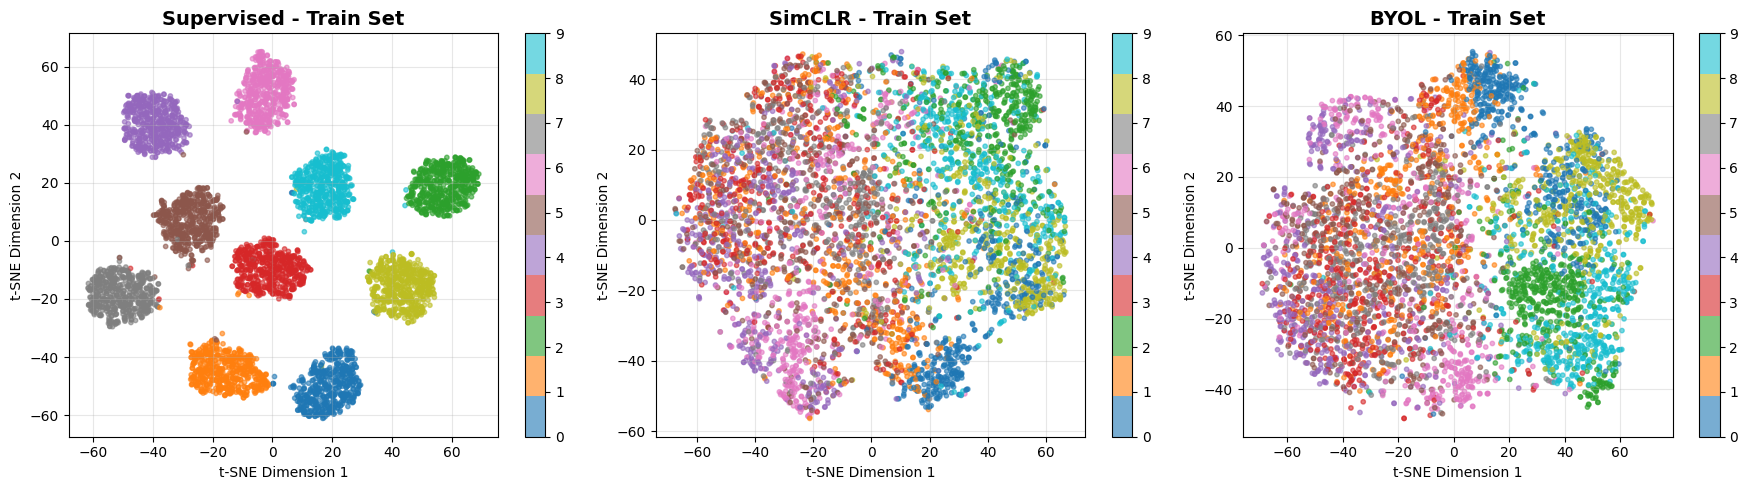

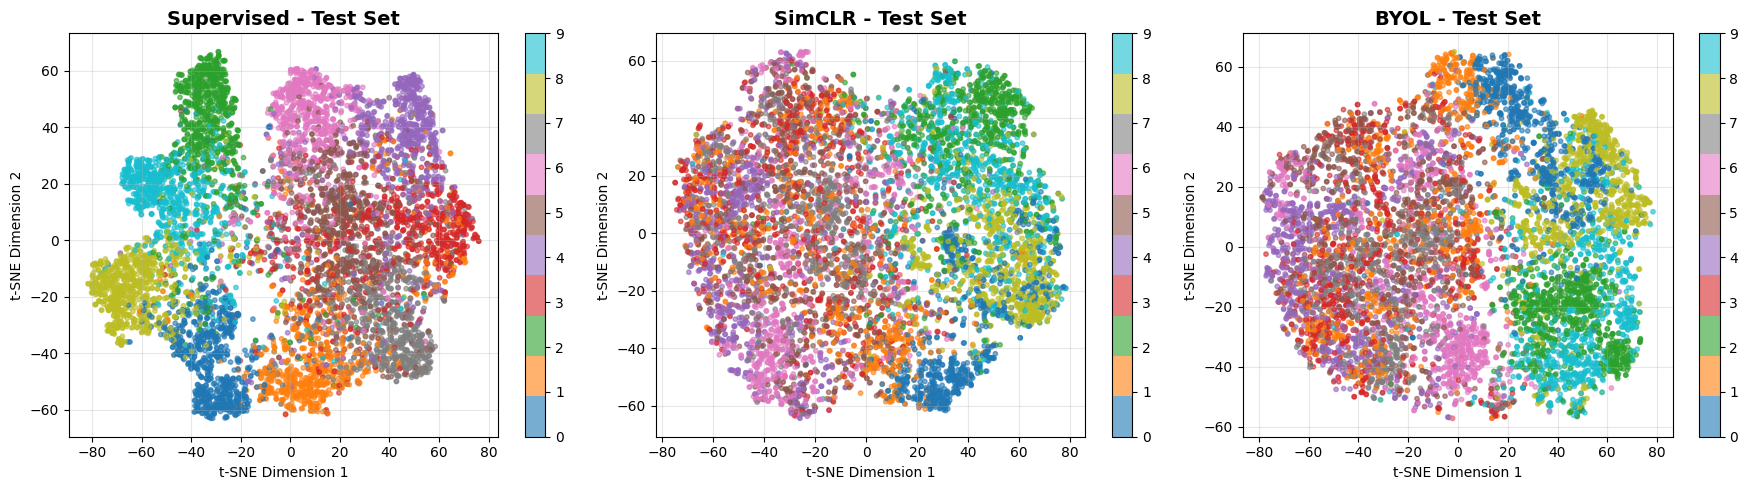

In [ ]:
test_loader = get_stl10_dataloaders('test', 128, 'supervised')
train_loader = get_stl10_dataloaders('train', 128, 'supervised')

supervised_model = SupervisedModel().to(Config.DEVICE)
state_dict = torch.load('checkpoints/supervised_baseline.pth', map_location=Config.DEVICE)
state_dict = strip_prefix_from_state_dict(state_dict)
supervised_model.load_state_dict(state_dict)

simclr_model = SimCLR().to(Config.DEVICE)
state_dict = torch.load('checkpoints/simclr_model_40.pth', map_location=Config.DEVICE)
state_dict = strip_prefix_from_state_dict(state_dict)
simclr_model.load_state_dict(state_dict)

byol_model = BYOL().to(Config.DEVICE)
state_dict = torch.load('checkpoints/byol_model_40.pth', map_location=Config.DEVICE)
state_dict = strip_prefix_from_state_dict(state_dict)
byol_model.load_state_dict(state_dict)

print("Models loaded successfully!")

print("Extracting embeddings...")
emb_sup_train, labels_sup_train = extract_embeddings(supervised_model.model, train_loader, Config.DEVICE, is_ssl=False)
emb_simclr_train, labels_simclr_train = extract_embeddings(simclr_model, train_loader, Config.DEVICE, is_ssl=True)
emb_byol_train, labels_byol_train = extract_embeddings(byol_model, train_loader, Config.DEVICE, is_ssl=True)

emb_sup_test, labels_sup_test = extract_embeddings(supervised_model.model, test_loader, Config.DEVICE, is_ssl=False)
emb_simclr_test, labels_simclr_test = extract_embeddings(simclr_model, test_loader, Config.DEVICE, is_ssl=True)
emb_byol_test, labels_byol_test = extract_embeddings(byol_model, test_loader, Config.DEVICE, is_ssl=True)

print("Computing t-SNE (this may take a while)...")
tsne = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=1000)

tsne_sup_train = tsne.fit_transform(emb_sup_train)
tsne_simclr_train = tsne.fit_transform(emb_simclr_train)
tsne_byol_train = tsne.fit_transform(emb_byol_train)

tsne_sup_test = tsne.fit_transform(emb_sup_test)
tsne_simclr_test = tsne.fit_transform(emb_simclr_test)
tsne_byol_test = tsne.fit_transform(emb_byol_test)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
titles = ['Supervised', 'SimCLR', 'BYOL']
tsne_results = [tsne_sup_train, tsne_simclr_train, tsne_byol_train]
labels_list = [labels_sup_train, labels_simclr_train, labels_byol_train]

for ax, title, tsne_res, labels in zip(axes, titles, tsne_results, labels_list):
    scatter = ax.scatter(tsne_res[:, 0], tsne_res[:, 1], c=labels, cmap='tab10', alpha=0.6, s=10)
    ax.set_title(f'{title} - Train Set', fontsize=14, fontweight='bold')
    ax.set_xlabel('t-SNE Dimension 1')
    ax.set_ylabel('t-SNE Dimension 2')
    ax.grid(True, alpha=0.3)
    plt.colorbar(scatter, ax=ax, ticks=range(10))

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
tsne_results = [tsne_sup_test, tsne_simclr_test, tsne_byol_test]
labels_list = [labels_sup_test, labels_simclr_test, labels_byol_test]

for ax, title, tsne_res, labels in zip(axes, titles, tsne_results, labels_list):
    scatter = ax.scatter(tsne_res[:, 0], tsne_res[:, 1], c=labels, cmap='tab10', alpha=0.6, s=10)
    ax.set_title(f'{title} - Test Set', fontsize=14, fontweight='bold')
    ax.set_xlabel('t-SNE Dimension 1')
    ax.set_ylabel('t-SNE Dimension 2')
    ax.grid(True, alpha=0.3)
    plt.colorbar(scatter, ax=ax, ticks=range(10))

plt.tight_layout()
plt.show()

## 4. Linear probing [1 pts]

Train a linear probe for self-supervised models, compare the quality with supervised training.

In [4]:
print("="*60)
print("Linear Probing for SimCLR, BYOL, MoCo")
print("="*60)

# !python scripts/linear_probe.py

Linear Probing for SimCLR, BYOL, MoCo


In [7]:
with open('results/simclr_linear_probe_metrics.json', 'r') as f:
    simclr_lp = json.load(f)
with open('results/byol_linear_probe_metrics.json', 'r') as f:
    byol_lp = json.load(f)
with open('results/supervised_metrics.json', 'r') as f:
    supervised = json.load(f)
with open('results/moco_linear_probe_metrics.json', 'r') as f:
    moco_lp = json.load(f)

print("\n" + "="*60)
print("Linear Probing Results")
print("="*60)
print(f"Supervised Baseline:      {supervised['test_accs'][-1]:.2f}%")
print(f"SimCLR + Linear Probe:    {simclr_lp['test_accs'][-1]:.2f}%")
print(f"BYOL + Linear Probe:      {byol_lp['test_accs'][-1]:.2f}%")
print(f"MoCo + Linear Probe:      {moco_lp['test_accs'][-1]:.2f}%")
print("="*60)



Linear Probing Results
Supervised Baseline:      74.51%
SimCLR + Linear Probe:    55.71%
BYOL + Linear Probe:      64.76%
MoCo + Linear Probe:      57.30%


## 5. Fine-tuning [1.5 pts]

Finally, fine-tune the self-supervised models to STL-10 classification. If you did everything correctly, the quality should be several percent higher than that of the baseline. Similar to task 3, draw how the embeddings changed after the fine-tuning process.

In [8]:
print("="*60)
print("Fine-tuning SimCLR, BYOL, MoCo")
print("="*60)

# !python scripts/finetune.py

Fine-tuning SimCLR, BYOL, MoCo


Fine-tuning SimCLR, BYOL

Fine-tuning Results
Supervised Baseline:      74.51%
SimCLR + Linear Probe:    55.71%
SimCLR + Fine-tuning:     70.62%
BYOL + Linear Probe:      64.76%
BYOL + Fine-tuning:       74.86%
Extracting embeddings from fine-tuned models...


Computing t-SNE for fine-tuned models...


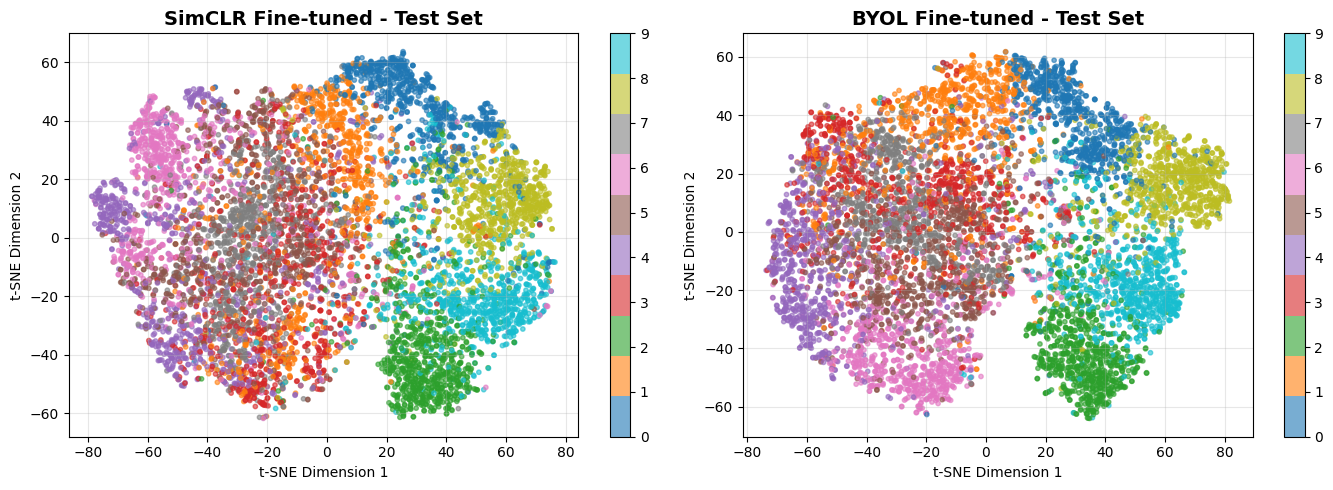

In [ ]:
with open('results/simclr_finetune_metrics.json', 'r') as f:
    simclr_ft = json.load(f)
with open('results/byol_finetune_metrics.json', 'r') as f:
    byol_ft = json.load(f)

print("\n" + "="*60)
print("Fine-tuning Results")
print("="*60)
print(f"Supervised Baseline:      {supervised['test_accs'][-1]:.2f}%")
print(f"SimCLR + Linear Probe:    {simclr_lp['test_accs'][-1]:.2f}%")
print(f"SimCLR + Fine-tuning:     {simclr_ft['test_accs'][-1]:.2f}%")
print(f"BYOL + Linear Probe:      {byol_lp['test_accs'][-1]:.2f}%")
print(f"BYOL + Fine-tuning:       {byol_ft['test_accs'][-1]:.2f}%")
print("="*60)

test_loader = get_stl10_dataloaders('test', 128, 'supervised')

simclr_ft_model = resnet18(num_classes=10)
state_dict = torch.load('checkpoints/simclr_finetuned.pth', map_location=Config.DEVICE)
state_dict = strip_prefix_from_state_dict(state_dict)
simclr_ft_model.load_state_dict(state_dict)
simclr_ft_model = simclr_ft_model.to(Config.DEVICE)

byol_ft_model = resnet18(num_classes=10)
state_dict = torch.load('checkpoints/byol_finetuned.pth', map_location=Config.DEVICE)
state_dict = strip_prefix_from_state_dict(state_dict)
byol_ft_model.load_state_dict(state_dict)
byol_ft_model = byol_ft_model.to(Config.DEVICE)

print("Extracting embeddings from fine-tuned models...")
emb_simclr_ft, labels_simclr_ft = extract_embeddings(simclr_ft_model, test_loader, Config.DEVICE, is_ssl=False)
emb_byol_ft, labels_byol_ft = extract_embeddings(byol_ft_model, test_loader, Config.DEVICE, is_ssl=False)

print("Computing t-SNE for fine-tuned models...")
tsne = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=1000)
tsne_simclr_ft = tsne.fit_transform(emb_simclr_ft)
tsne_byol_ft = tsne.fit_transform(emb_byol_ft)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
titles = ['SimCLR Fine-tuned', 'BYOL Fine-tuned']
tsne_results = [tsne_simclr_ft, tsne_byol_ft]
labels_list = [labels_simclr_ft, labels_byol_ft]

for ax, title, tsne_res, labels in zip(axes, titles, tsne_results, labels_list):
    scatter = ax.scatter(tsne_res[:, 0], tsne_res[:, 1], c=labels, cmap='tab10', alpha=0.6, s=10)
    ax.set_title(f'{title} - Test Set', fontsize=14, fontweight='bold')
    ax.set_xlabel('t-SNE Dimension 1')
    ax.set_ylabel('t-SNE Dimension 2')
    ax.grid(True, alpha=0.3)
    plt.colorbar(scatter, ax=ax, ticks=range(10))

plt.tight_layout()
plt.show()


## 6. OOD robustness [2 pts]

Now, we have 5 different models:

- Supervised
- SimCLR + linear probing
- SimCLR + fine-tuning
- BYOL + linear probing
- BYOL + fine-tuning

We will compare the models by robustness on out-of-distribution objects. As an OOD dataset, we will take the CIFAR-10 test sample, which has almost the same classes as STL-10 (9/10 classes).
The only mismatch in CIFAR-10 is the "frog" class, so drop the images of this class. Compare the trained models by OOD accuracy.

In [ ]:
print("="*60)
print("Evaluating OOD Robustness on CIFAR-10")
print("="*60)

# !python scripts/evaluate_ood.py

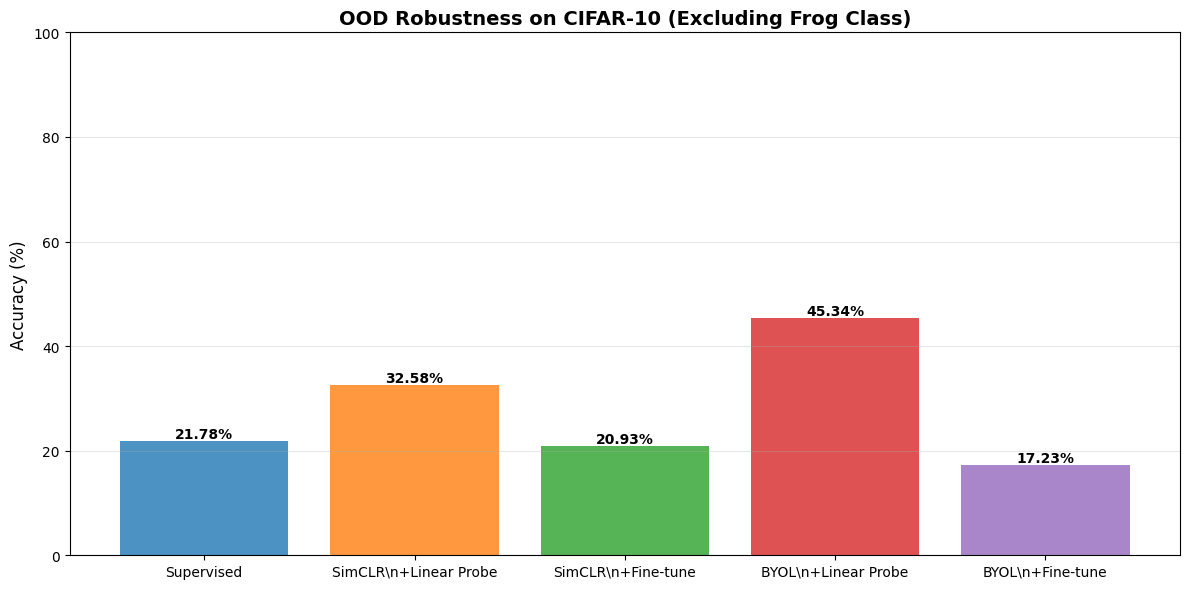


OOD Robustness Results Summary
Supervised          :  21.78%
SimCLR+LP           :  32.58%
SimCLR+FT           :  20.93%
BYOL+LP             :  45.34%
BYOL+FT             :  17.23%


In [8]:
with open('results/ood_results.json', 'r') as f:
    ood_results = json.load(f)

has_moco_results = 'moco_linear_probe' in ood_results and 'moco_finetuned' in ood_results

if has_moco_results:
    model_names = [
        'Supervised',
        'SimCLR\\n+Linear Probe',
        'SimCLR\\n+Fine-tune',
        'BYOL\\n+Linear Probe',
        'BYOL\\n+Fine-tune'
    ]
    
    accuracies = [
        ood_results['supervised'],
        ood_results['simclr_linear_probe'],
        ood_results['simclr_finetuned'],
        ood_results['byol_linear_probe'],
        ood_results['byol_finetuned']
    ]
    
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2']
else:
    model_names = [
        'Supervised',
        'SimCLR\\n+Linear Probe',
        'SimCLR\\n+Fine-tune',
        'BYOL\\n+Linear Probe',
        'BYOL\\n+Fine-tune'
    ]
    
    accuracies = [
        ood_results['supervised'],
        ood_results['simclr_linear_probe'],
        ood_results['simclr_finetuned'],
        ood_results['byol_linear_probe'],
        ood_results['byol_finetuned']
    ]
    
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.bar(model_names, accuracies, color=colors, alpha=0.8)

ax.set_ylabel('Accuracy (%)', fontsize=12)
ax.set_title('OOD Robustness on CIFAR-10 (Excluding Frog Class)', fontsize=14, fontweight='bold')
ax.set_ylim([0, 100])
ax.grid(True, alpha=0.3, axis='y')

for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.2f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("OOD Robustness Results Summary")
print("="*60)
if has_moco_results:
    summary_names = ['Supervised', 'SimCLR+LP', 'SimCLR+FT', 'BYOL+LP', 'BYOL+FT']
else:
    summary_names = ['Supervised', 'SimCLR+LP', 'SimCLR+FT', 'BYOL+LP', 'BYOL+FT']
for name, acc in zip(summary_names, accuracies):
    print(f"{name:<20}: {acc:>6.2f}%")
print("="*60)


## Bonus. MoCo [2 pts]

As a bonus, let's look at another contrastive self-supervised model, MoCov2, from [He et al, 2019](https://arxiv.org/pdf/1911.05722), [He et al, 2020](https://arxiv.org/pdf/2003.04297.pdf). Conduct all the experiments described above with this model.

In [ ]:
print("="*60)
print("Training MoCo (Bonus)")
print("="*60)

# !python scripts/train_moco.py

Training MoCo (Bonus)



FINAL RESULTS SUMMARY (Including MoCo)
                Model  STL-10 Test Acc (%)  CIFAR-10 OOD Acc (%)
           Supervised                74.51                 21.78
SimCLR + Linear Probe                55.71                 32.58
 SimCLR + Fine-tuning                70.62                 20.93
  BYOL + Linear Probe                64.76                 45.34
   BYOL + Fine-tuning                74.86                 17.23
  MoCo + Linear Probe                57.30                 45.68
   MoCo + Fine-tuning                72.95                 20.02


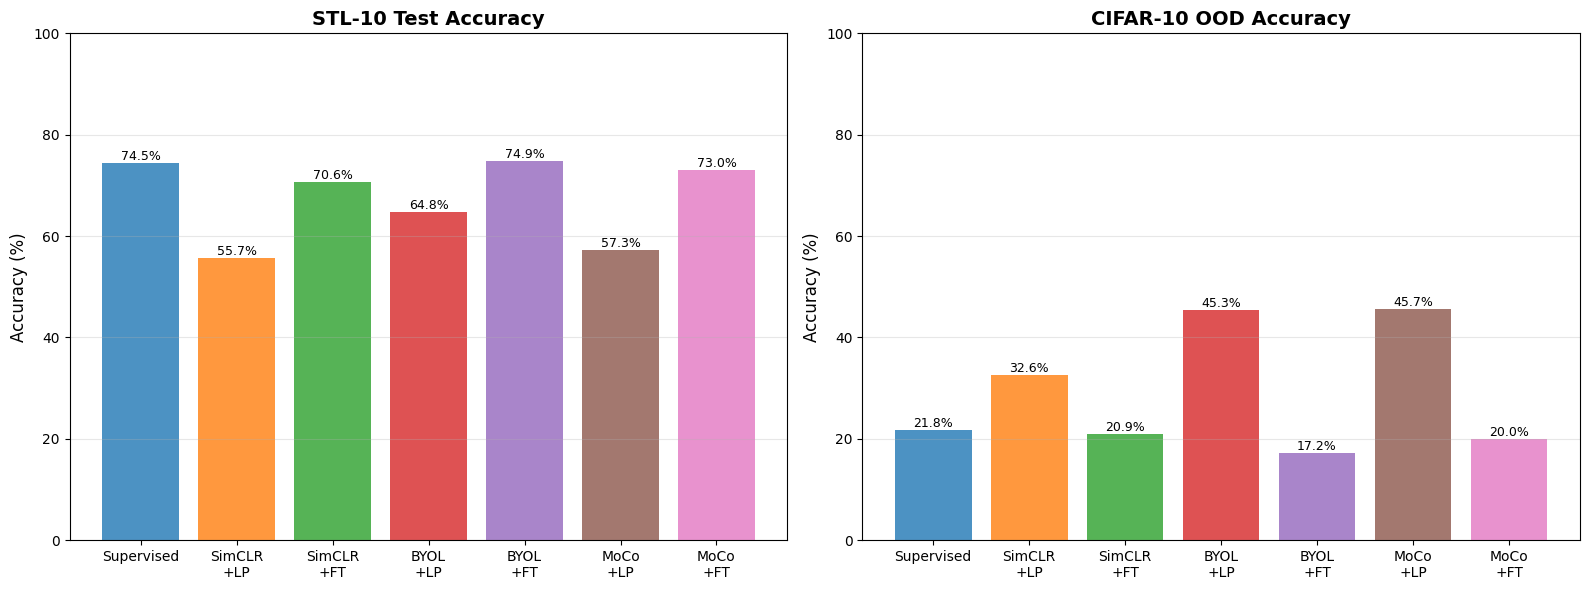

In [6]:
with open('results/supervised_metrics.json', 'r') as f:
    supervised = json.load(f)
with open('results/simclr_linear_probe_metrics.json', 'r') as f:
    simclr_lp = json.load(f)
with open('results/simclr_finetune_metrics.json', 'r') as f:
    simclr_ft = json.load(f)
with open('results/byol_linear_probe_metrics.json', 'r') as f:
    byol_lp = json.load(f)
with open('results/byol_finetune_metrics.json', 'r') as f:
    byol_ft = json.load(f)

try:
    with open('results/moco_linear_probe_metrics.json', 'r') as f:
        moco_lp = json.load(f)
    with open('results/moco_finetune_metrics.json', 'r') as f:
        moco_ft = json.load(f)
    has_moco = True
except FileNotFoundError:
    has_moco = False
    print("Note: MoCo results not found. Run MoCo training, linear probing, and fine-tuning first.")

with open('results/ood_results.json', 'r') as f:
    ood_results = json.load(f)

if has_moco and 'moco_linear_probe' in ood_results:
    summary_data = {
        'Model': [
            'Supervised',
            'SimCLR + Linear Probe',
            'SimCLR + Fine-tuning',
            'BYOL + Linear Probe',
            'BYOL + Fine-tuning',
            'MoCo + Linear Probe',
            'MoCo + Fine-tuning'
        ],
        'STL-10 Test Acc (%)': [
            supervised['test_accs'][-1],
            simclr_lp['test_accs'][-1],
            simclr_ft['test_accs'][-1],
            byol_lp['test_accs'][-1],
            byol_ft['test_accs'][-1],
            moco_lp['test_accs'][-1],
            moco_ft['test_accs'][-1]
        ],
        'CIFAR-10 OOD Acc (%)': [
            ood_results['supervised'],
            ood_results['simclr_linear_probe'],
            ood_results['simclr_finetuned'],
            ood_results['byol_linear_probe'],
            ood_results['byol_finetuned'],
            ood_results['moco_linear_probe'],
            ood_results['moco_finetuned']
        ]
    }
else:
    summary_data = {
        'Model': [
            'Supervised',
            'SimCLR + Linear Probe',
            'SimCLR + Fine-tuning',
            'BYOL + Linear Probe',
            'BYOL + Fine-tuning'
        ],
        'STL-10 Test Acc (%)': [
            supervised['test_accs'][-1],
            simclr_lp['test_accs'][-1],
            simclr_ft['test_accs'][-1],
            byol_lp['test_accs'][-1],
            byol_ft['test_accs'][-1]
        ],
        'CIFAR-10 OOD Acc (%)': [
            ood_results['supervised'],
            ood_results['simclr_linear_probe'],
            ood_results['simclr_finetuned'],
            ood_results['byol_linear_probe'],
            ood_results['byol_finetuned']
        ]
    }

df = pd.DataFrame(summary_data)
df = df.round(2)

print("\n" + "="*70)
print("FINAL RESULTS SUMMARY (Including MoCo)")
print("="*70)
print(df.to_string(index=False))
print("="*70)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

models = ['Supervised', 'SimCLR\n+LP', 'SimCLR\n+FT', 'BYOL\n+LP', 'BYOL\n+FT', 'MoCo\n+LP', 'MoCo\n+FT']
stl_accs = df['STL-10 Test Acc (%)'].values
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2']

bars1 = ax1.bar(models, stl_accs, color=colors, alpha=0.8)
ax1.set_ylabel('Accuracy (%)', fontsize=12)
ax1.set_title('STL-10 Test Accuracy', fontsize=14, fontweight='bold')
ax1.set_ylim([0, 100])
ax1.grid(True, alpha=0.3, axis='y')
for bar in bars1:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height, f'{height:.1f}%',
            ha='center', va='bottom', fontsize=9)

ood_accs = df['CIFAR-10 OOD Acc (%)'].values
bars2 = ax2.bar(models, ood_accs, color=colors, alpha=0.8)
ax2.set_ylabel('Accuracy (%)', fontsize=12)
ax2.set_title('CIFAR-10 OOD Accuracy', fontsize=14, fontweight='bold')
ax2.set_ylim([0, 100])
ax2.grid(True, alpha=0.3, axis='y')
for bar in bars2:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height, f'{height:.1f}%',
            ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()
